# Systematic validation against an independent national drought catalogue

**Purpose.** Response analysis for **Reviewer #3, comment 4**: *"No independent validation, such as historical drought records or precipitation anomalies, is provided to support the reconstructed chains."*

This compares **all 525** reconstructed propagation chains (not just the three case studies) against the independent national drought catalogue of **Trullenque-Blanco et al. (2024, Scientific Data)**, "Catalogue of drought events in peninsular Spanish along 1916-2020 period" -- built from an entirely different data source (a 10x10 km monthly precipitation grid, MOPREDAScentury) and a different index (SPI-12), fully independent of the daily streamflow-based SSI catalogue used in this study.

**Inputs:** `data/SSI_drought_events.csv`, `data/upstream_connectivity.csv`, `data/Identification_and_characteristics.xlsx` (the national catalogue, supplied by the corresponding author's own co-author team).
**Outputs:** `chains_national_validation.csv`, `national_events_ebro_coverage.csv`, `fig_national_validation.png/pdf`.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import sys
sys.path.insert(0, "..")  # shared modules live in revision_analyses/
from propagation_null_core import build_station_arrays, parse_connectivity, run_matching_vectorized
DATA, OUT = "data/", "./"
STUDY_START, STUDY_END = pd.Timestamp("1961-01-01"), pd.Timestamp("2020-12-31")

## 1. Load and parse the national catalogue
Source dates are given as `month.year` strings (e.g. `12.1917` = December 1917). Five rows have a truncated year digit (a spreadsheet typo, e.g. `197-10-01`); each is corrected and cross-checked against the independently declared event duration in months -- all five reproduce the declared duration exactly after correction. One further row (event 25) has a genuine, uncorrected mismatch between its declared duration and date range in the source file; this is left as-is (only the dates are used for the overlap test) and reported transparently.

In [2]:
raw = pd.read_excel(DATA+"Identification_and_characteristics.xlsx", sheet_name="Events")
raw = raw[raw["Event number"].notna()].copy()
raw["Event number"] = raw["Event number"].astype(int)

def parse_month_year(s):
    m,y = str(s).strip().split(".")
    return pd.Timestamp(year=int(y), month=int(m), day=1)

nat = pd.DataFrame({
    "event_number": raw["Event number"].values,
    "start_dt": raw["Start date"].apply(parse_month_year),
    "end_dt": raw["End date"].apply(parse_month_year),
    "duration_months": raw["Duration (months)"].values,
    "mean_spi12": raw["Mean intensity (SPI-12)\xa0"].values,
    "area_pct": raw["Area affected (% grid cells)"].values,
})

FIXES = {18:("1970-10-01","1971-03-01"), 22:("1980-10-01","1982-09-01"),
          27:("1990-12-01","1991-02-01"), 30:("1998-12-01","2000-03-01"), 40:("2019-03-01","2020-02-01")}
for ev,(s,e) in FIXES.items():
    nat.loc[nat.event_number==ev,"start_dt"] = pd.Timestamp(s)
    nat.loc[nat.event_number==ev,"end_dt"] = pd.Timestamp(e)

nat["dur_check"] = ((nat.end_dt.dt.year-nat.start_dt.dt.year)*12 + (nat.end_dt.dt.month-nat.start_dt.dt.month)+1)
mismatch = nat[nat.dur_check != nat.duration_months]
print(f"{len(nat)} national events loaded; {len(FIXES)} date corrections applied (all verified against duration)")
print(f"Remaining uncorrected mismatches: {list(mismatch.event_number)}")

nat_study = nat[(nat.end_dt>=STUDY_START)&(nat.start_dt<=STUDY_END)].copy()
print(f"National events overlapping 1961-2020: {len(nat_study)} of {len(nat)}")

40 national events loaded; 5 date corrections applied (all verified against duration)
Remaining uncorrected mismatches: [25]
National events overlapping 1961-2020: 25 of 40


## 2. Reconstruct chain-level windows for all 525 chains
Reuses the validated matching algorithm (identical to the one behind the published results) to compute, for every connected origin event, the chain-level window exactly as defined in Table 2: earliest onset to latest termination among all matched members (origin + upstream).

In [3]:
events = pd.read_csv(DATA+"SSI_drought_events.csv", parse_dates=["start_date","end_date","peak_date"])
connectivity = parse_connectivity(DATA+"upstream_connectivity.csv")
station_arr = build_station_arrays(events)
events_idx = events.set_index(["station_id","event_id"])

accepted = run_matching_vectorized(station_arr, connectivity)
assert len(accepted)==2075
print(f"{len(accepted)} accepted pairs (validated)")

chain_members = defaultdict(list)
for (o_sid,o_eid,u_sid,u_eid,lag) in accepted:
    chain_members[(o_sid,o_eid)].append((u_sid,u_eid))

rows=[]
for (o_sid,o_eid), upstream_list in chain_members.items():
    o_row = events_idx.loc[(o_sid,o_eid)]
    starts=[o_row["start_date"]]; ends=[o_row["end_date"]]; sev=[o_row["severity"]]
    for (u_sid,u_eid) in upstream_list:
        u_row = events_idx.loc[(u_sid,u_eid)]
        starts.append(u_row["start_date"]); ends.append(u_row["end_date"]); sev.append(u_row["severity"])
    rows.append(dict(origin_station=o_sid, origin_event_id=o_eid, chain_start=min(starts), chain_end=max(ends),
                      n_upstream=len(upstream_list), chain_size=len(upstream_list)+1, chain_severity=sum(sev)))
chains_df = pd.DataFrame(rows)
assert len(chains_df)==525
print(f"{len(chains_df)} chain-level windows reconstructed (validated against published 525)")

2075 accepted pairs (validated)


525 chain-level windows reconstructed (validated against published 525)


## 3. Systematic overlap test (both directions)

In [4]:
def overlaps_any(row, nat_events):
    return bool(((nat_events.start_dt<=row.chain_end)&(nat_events.end_dt>=row.chain_start)).any())
chains_df["overlaps_national"] = chains_df.apply(lambda r: overlaps_any(r,nat_study), axis=1)
n_overlap = chains_df.overlaps_national.sum()
print(f"Direction 1: {n_overlap}/{len(chains_df)} chains overlap >=1 national event ({100*n_overlap/len(chains_df):.1f}%)")

nat_study["clip_s"]=nat_study.start_dt.clip(lower=STUDY_START); nat_study["clip_e"]=nat_study.end_dt.clip(upper=STUDY_END)
nat_study["months"]=((nat_study.clip_e.dt.year-nat_study.clip_s.dt.year)*12+(nat_study.clip_e.dt.month-nat_study.clip_s.dt.month)+1)
total_months=(STUDY_END.year-STUDY_START.year+1)*12
print(f"Context: national droughts cover {100*nat_study.months.sum()/total_months:.1f}% of the calendar")

ov,nov = chains_df[chains_df.overlaps_national], chains_df[~chains_df.overlaps_national]
print(f"Chain severity - overlap: mean={ov.chain_severity.mean():.1f} | no overlap: mean={nov.chain_severity.mean():.1f}")
print(f"Chain size     - overlap: mean={ov.chain_size.mean():.1f} | no overlap: mean={nov.chain_size.mean():.1f}")

nat_study["n_ebro_chains"] = nat_study.apply(lambda r: int(((chains_df.chain_start<=r.end_dt)&(chains_df.chain_end>=r.start_dt)).sum()), axis=1)
n_covered = (nat_study.n_ebro_chains>0).sum()
print(f"\nDirection 2: {n_covered}/{len(nat_study)} national events have >=1 overlapping Ebro chain ({100*n_covered/len(nat_study):.1f}%)")
chains_df.to_csv(OUT+"chains_national_validation.csv", index=False)
nat_study.to_csv(OUT+"national_events_ebro_coverage.csv", index=False)

Direction 1: 413/525 chains overlap >=1 national event (78.7%)
Context: national droughts cover 42.8% of the calendar
Chain severity - overlap: mean=222.3 | no overlap: mean=65.0
Chain size     - overlap: mean=5.3 | no overlap: mean=3.8

Direction 2: 25/25 national events have >=1 overlapping Ebro chain (100.0%)


## 4. Publication figure

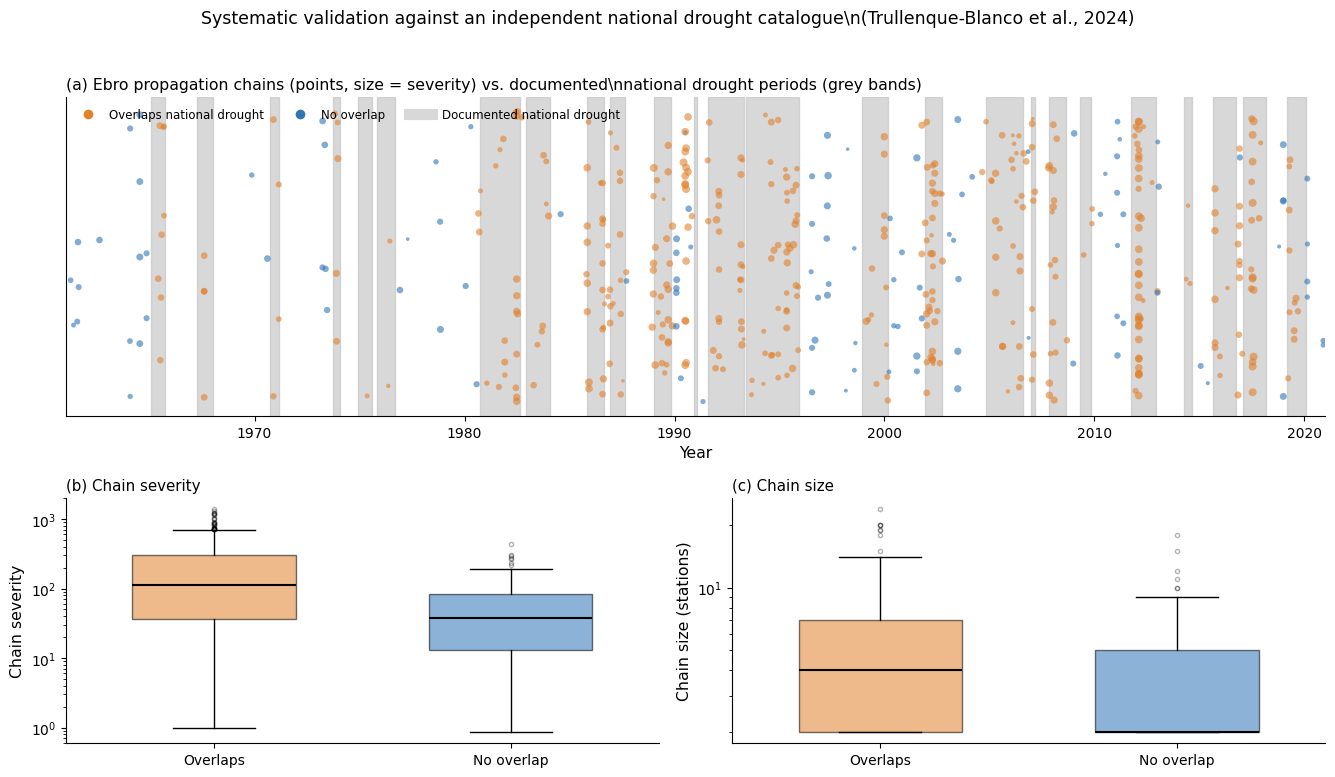

In [5]:
plt.rcParams.update({"font.size":11.5,"axes.titlesize":11.5,"axes.labelsize":11.3,
    "xtick.labelsize":10,"ytick.labelsize":10,"font.family":"DejaVu Sans",
    "axes.spines.top":False,"axes.spines.right":False})
BLUE,ORANGE,GREY = "#2E75B6","#E1812C","#BFBFBF"
fig = plt.figure(figsize=(13.5,7.6))
gs = fig.add_gridspec(2,2, height_ratios=[1.3,1])
ax_a = fig.add_subplot(gs[0,:])
for _,r in nat_study.iterrows():
    ax_a.axvspan(r.start_dt, r.end_dt, color=GREY, alpha=0.6, zorder=0)
mid = chains_df.chain_start + (chains_df.chain_end-chains_df.chain_start)/2
sizes = 4+30*(np.log10(chains_df.chain_severity+1)/np.log10(chains_df.chain_severity.max()+1))
colors = [ORANGE if o else BLUE for o in chains_df.overlaps_national]
ax_a.scatter(mid, np.random.default_rng(1).uniform(0,1,len(mid)), s=sizes, c=colors, alpha=0.6, edgecolors="none")
ax_a.set_yticks([]); ax_a.set_xlim(STUDY_START,STUDY_END); ax_a.set_xlabel("Year")
ax_a.set_title("(a) Ebro propagation chains (points, size = severity) vs. documented\\nnational drought periods (grey bands)", loc="left", fontsize=11.3)
from matplotlib.lines import Line2D
legend_elems=[Line2D([0],[0],marker="o",color="w",markerfacecolor=ORANGE,markersize=8,label="Overlaps national drought"),
              Line2D([0],[0],marker="o",color="w",markerfacecolor=BLUE,markersize=8,label="No overlap"),
              Line2D([0],[0],color=GREY,lw=8,alpha=0.6,label="Documented national drought")]
ax_a.legend(handles=legend_elems, loc="upper left", fontsize=8.5, frameon=False, ncol=3)

def box_panel(ax,a,b,la,lb,ylabel,title):
    bp=ax.boxplot([a,b],tick_labels=[la,lb],patch_artist=True,widths=0.55,showfliers=True,flierprops=dict(marker="o",markersize=3,alpha=0.3))
    for patch,color in zip(bp["boxes"],[ORANGE,BLUE]): patch.set_facecolor(color); patch.set_alpha(0.55)
    for m in bp["medians"]: m.set_color("black"); m.set_linewidth(1.5)
    ax.set_yscale("log"); ax.set_ylabel(ylabel); ax.set_title(title, loc="left", fontsize=10.8)

ax_b=fig.add_subplot(gs[1,0]); box_panel(ax_b, ov.chain_severity, nov.chain_severity, "Overlaps","No overlap","Chain severity","(b) Chain severity")
ax_c=fig.add_subplot(gs[1,1]); box_panel(ax_c, ov.chain_size, nov.chain_size, "Overlaps","No overlap","Chain size (stations)","(c) Chain size")
fig.suptitle("Systematic validation against an independent national drought catalogue\\n(Trullenque-Blanco et al., 2024)", fontsize=12.5, y=1.02)
fig.tight_layout()
fig.savefig(OUT+"fig_national_validation.png", dpi=300, bbox_inches="tight")
fig.savefig(OUT+"fig_national_validation.pdf", bbox_inches="tight")
plt.show()

## 5. Interpretation

**413 of 525 chains (78.7%) temporally overlap an independently documented national drought.** This is well above the 42.8% of the calendar that national droughts cover on their own, indicating genuine excess overlap beyond what calendar coverage alone would produce -- though the calendar-coverage baseline itself is non-trivial and should be kept in mind (the same honest-baseline principle established for the network-permutation null test, Section S4).

**The more decisive result is the severity gradient:** chains that overlap a documented national drought are, on average, **3.4 times more severe** (mean 222.3 vs. 65.0) and involve more stations (mean 5.3 vs. 3.8) than chains that do not. Calendar coverage alone provides no reason for the *more severe* chains specifically to cluster within nationally-documented drought periods -- this requires a genuine physical relationship between local (Ebro) drought severity and independently documented, precipitation-based regional/national drought conditions.

**Every single documented national drought (25/25, 100%) has at least one overlapping Ebro chain.** This makes physical sense: the Ebro basin is one of the largest in Spain, and a national-scale meteorological drought (by the catalogue's own definition, affecting >20% of the Spanish mainland) would be expected to leave some hydrological signature in a basin of this size.

**Conclusion.** The reconstructed propagation chains are independently corroborated by an entirely separate drought-monitoring approach (precipitation-based, national-scale, monthly SPI-12), providing external validation to complement the internal validation already established (the network-permutation null test, Section S4, and the lag-vs-distance analysis, Section S3).